In [1]:
# ==========================================
# APP 1 ANALYTICS (FINAL — COMPLETE TAB3 MATCH)
# ==========================================

import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import pickle

# ============================
# REQUIRED FUNCTION (FOR PIPELINE UNPICKLING)
# ============================

def add_career_score(X):

    X = X.copy()

    X["Career Score"] = (
        X["Years of Experience"] +
        (X["Education Level"] * 2)
    )

    return X[
        [
            "Years of Experience",
            "Education Level",
            "Career Score"
        ]
    ]

# ============================
# LOAD MODEL PACKAGE
# ============================

app1_package = joblib.load("model/rf_model_grid.pkl")
app1_model = app1_package["model"]

app1_cluster_package = joblib.load("model/career_cluster_pipeline.pkl")
app1_cluster_model = app1_cluster_package["model"]

# ============================
# LOAD DATA (MATCH MODEL INPUT)
# ============================

df_app1 = pd.read_csv("data/Salary.csv")
df_app1 = df_app1.drop_duplicates().reset_index(drop=True)

if "Race" in df_app1.columns:
    df_app1 = df_app1.drop("Race", axis=1)

# ============================
# REGRESSION DIAGNOSTICS
# ============================

X = df_app1.drop("Salary", axis=1)
y = df_app1["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = app1_model.predict(X_test)

y_test_np = y_test.values
y_pred_np = y_pred

residuals = y_test_np - y_pred_np
residual_std = np.std(residuals)
# ============================
# RANDOM FOREST UNCERTAINTY
# ============================

rf_model = app1_model.named_steps["model"]
preprocessor = app1_model.named_steps["preprocessor"]

sample_df = X_test.sample(min(100, len(X_test)), random_state=42)
processed_sample = preprocessor.transform(sample_df)

tree_preds = []

for tree in rf_model.estimators_:
    tree_preds.append(tree.predict(processed_sample))

tree_preds = np.array(tree_preds)
uncertainty = tree_preds.std(axis=0)

# ============================
# FEATURE IMPORTANCE
# ============================

feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importance_df["Original_Feature"] = importance_df["Feature"].apply(
    lambda x: x.split("_")[0]
)

grouped_importance = (
    importance_df
    .groupby("Original_Feature")["Importance"]
    .sum()
    .reset_index()
    .sort_values(by="Importance", ascending=False)
)

# IMPORTANT: match Tab3 ordering
grouped_importance = grouped_importance.iloc[::-1]

importance_sorted = importance_df.sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

importance_sorted["Cumulative Importance"] = (
    importance_sorted["Importance"].cumsum()
)

# ============================
# CLUSTER ANALYTICS
# ============================

X_cluster = df_app1[["Years of Experience", "Education Level"]]

cluster_labels = app1_cluster_model.predict(X_cluster)

X_engineered = app1_cluster_model.named_steps["career_score"].transform(X_cluster)
X_scaled = app1_cluster_model.named_steps["scaler"].transform(X_engineered)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

centroids_scaled = app1_cluster_model.named_steps["kmeans"].cluster_centers_
centroids_pca = pca.transform(centroids_scaled)

# ============================
# CLUSTER SCATTER DATA (NEW — MATCH TAB3)
# ============================

# IMPORTANT: must match clusterfinalfinal3.py mapping logic
# (sorted by experience)

cluster_means = (
    df_app1.assign(cluster=cluster_labels)
    .groupby("cluster")["Years of Experience"]
    .mean()
    .sort_values()
)

stage_names = ["Entry Stage", "Growth Stage", "Leadership Stage"]

cluster_to_stage = {
    int(cluster_id): stage_names[i]
    for i, cluster_id in enumerate(cluster_means.index)
}

cluster_plot_df = df_app1.copy()

cluster_plot_df["Career Stage"] = [
    cluster_to_stage.get(int(c), "Unknown") for c in cluster_labels
]

# ============================
# SAVE
# ============================

analytics_a1 = {
    # Regression diagnostics
    "y_test": y_test_np,
    "y_pred": y_pred_np,
    "residuals": residuals,
    "residual_std": residual_std,
    "uncertainty": uncertainty,

    # Feature importance
    "importance_df": importance_df,
    "grouped_importance": grouped_importance,
    "importance_sorted": importance_sorted,

    # Clustering
    "cluster_labels": cluster_labels,
    "X_pca": X_pca,
    "centroids_pca": centroids_pca,

    # NEW (for scatter plot)
    "cluster_plot_df": cluster_plot_df
}

with open("model/app1_analytics.pkl", "wb") as f:
    pickle.dump(analytics_a1, f)

print("APP 1 analytics saved successfully")

APP 1 analytics saved successfully


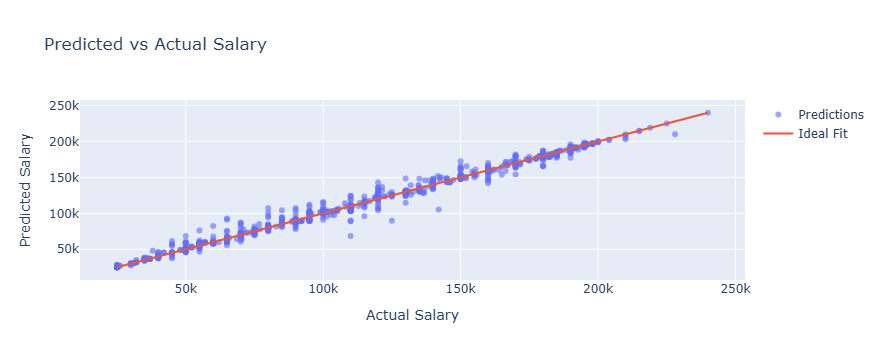

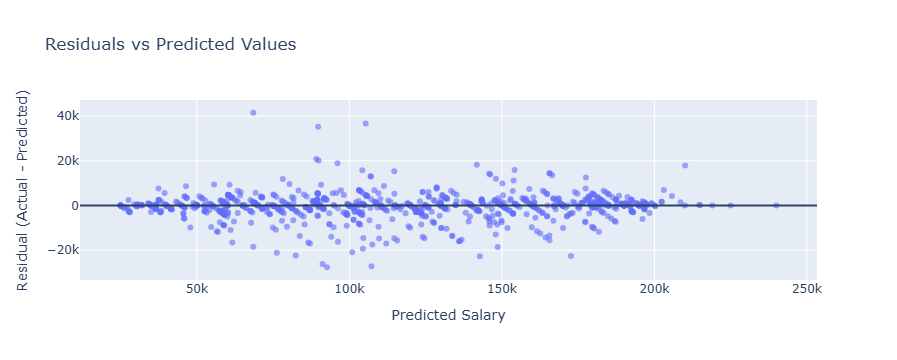

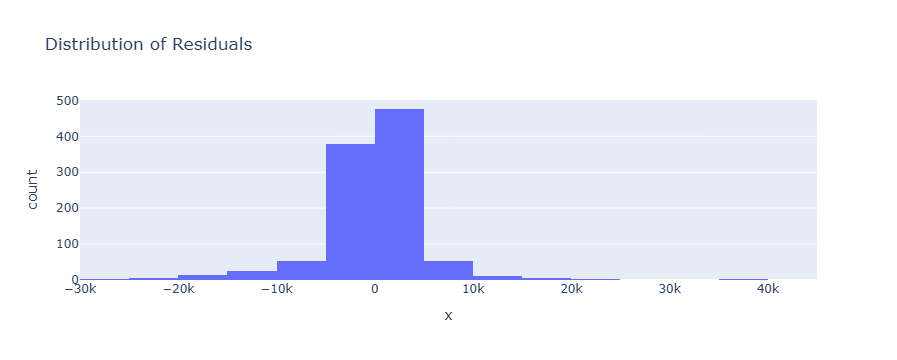

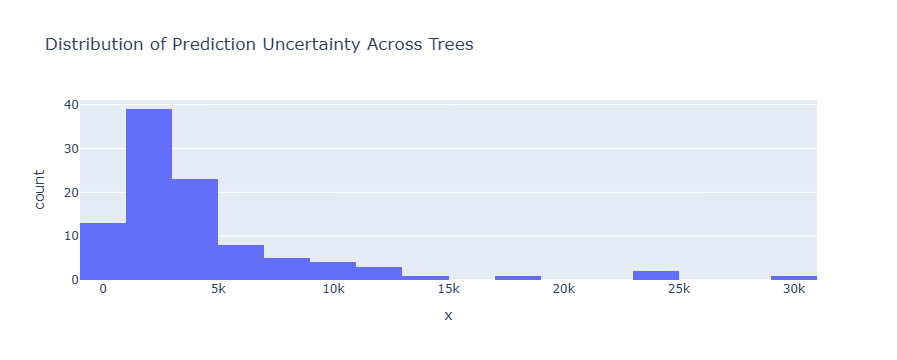

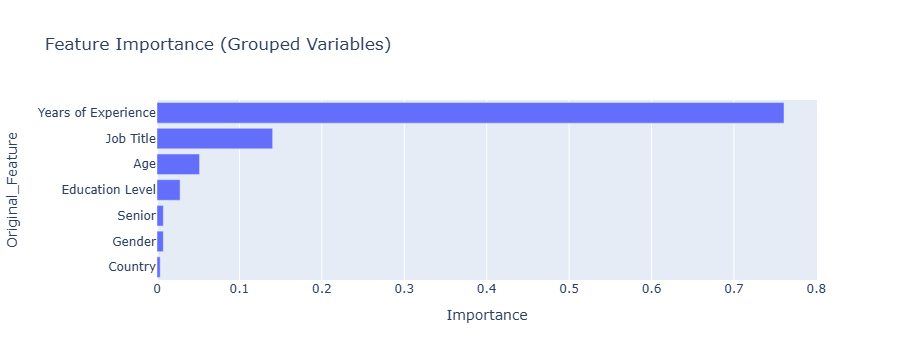

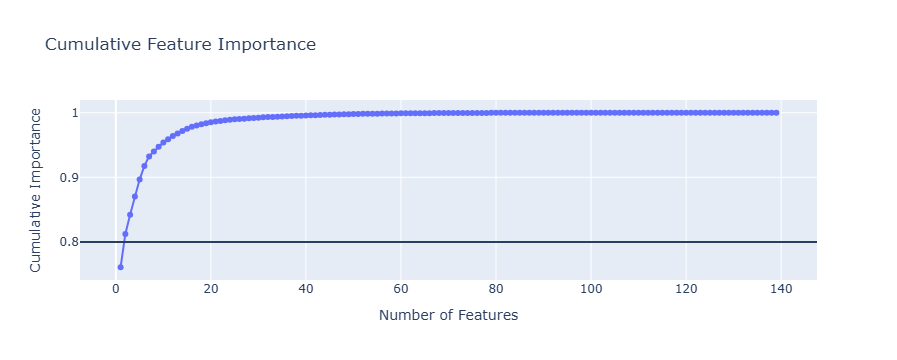

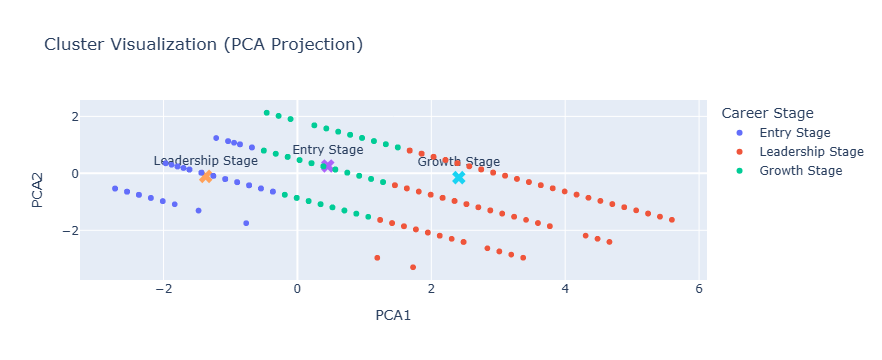

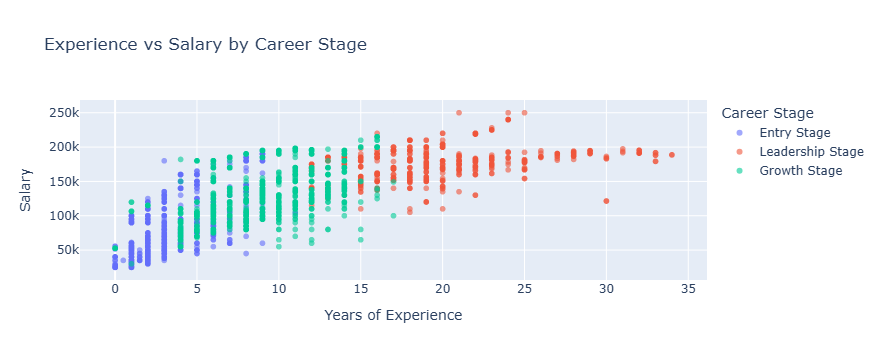

In [2]:
# ==========================================
# APP 1 — FULL TAB3 MATCH (PLOTLY FROM PICKLE)
# ==========================================

import pickle
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ============================
# LOAD ANALYTICS
# ============================

with open("model/app1_analytics.pkl", "rb") as f:
    analytics = pickle.load(f)

y_test = analytics["y_test"]
y_pred = analytics["y_pred"]
residuals = analytics["residuals"]
uncertainty = analytics["uncertainty"]

importance_df = analytics["importance_df"]
grouped_importance = analytics["grouped_importance"]
importance_sorted = analytics["importance_sorted"]

X_pca = analytics["X_pca"]
centroids_pca = analytics["centroids_pca"]
cluster_labels = analytics["cluster_labels"]
cluster_plot_df = analytics["cluster_plot_df"]
# ============================
# 1. PREDICTED VS ACTUAL (EXACT)
# ============================

fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=y_test,
    y=y_pred,
    mode="markers",
    name="Predictions",
    marker=dict(opacity=0.6)
))

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

fig1.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode="lines",
    name="Ideal Fit"
))

fig1.update_layout(
    title="Predicted vs Actual Salary",
    xaxis_title="Actual Salary",
    yaxis_title="Predicted Salary"
)

fig1.show()

# ============================
# 2. RESIDUAL SCATTER (EXACT)
# ============================

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=y_pred,
    y=residuals,
    mode="markers",
    marker=dict(opacity=0.6)
))

fig2.add_hline(y=0)

fig2.update_layout(
    title="Residuals vs Predicted Values",
    xaxis_title="Predicted Salary",
    yaxis_title="Residual (Actual - Predicted)"
)

fig2.show()

# ============================
# 3. RESIDUAL DISTRIBUTION (EXACT)
# ============================

fig3 = px.histogram(
    x=residuals,
    nbins=30,
    title="Distribution of Residuals"
)

fig3.show()

# ============================
# 4. RANDOM FOREST UNCERTAINTY (EXACT)
# ============================

fig4 = px.histogram(
    x=uncertainty,
    nbins=25,
    title="Distribution of Prediction Uncertainty Across Trees"
)

fig4.show()

# ============================
# 5. FEATURE IMPORTANCE (GROUPED — EXACT)
# ============================

fig5 = px.bar(
    grouped_importance,
    x="Importance",
    y="Original_Feature",
    orientation="h",
    title="Feature Importance (Grouped Variables)"
)

fig5.show()

# ============================
# 6. CUMULATIVE IMPORTANCE (EXACT)
# ============================

fig6 = px.line(
    importance_sorted,
    x=importance_sorted.index + 1,
    y="Cumulative Importance",
    title="Cumulative Feature Importance",
    markers=True
)

fig6.add_hline(y=0.80)

fig6.update_layout(
    xaxis_title="Number of Features",
    yaxis_title="Cumulative Importance"
)

fig6.show()

# ============================
# 7. PCA CLUSTER VISUALIZATION (CORRECT + SAFE)
# ============================

plot_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Career Stage": cluster_plot_df["Career Stage"]
})

fig7 = px.scatter(
    plot_df,
    x="PCA1",
    y="PCA2",
    color="Career Stage",
    title="Cluster Visualization (PCA Projection)"
)

# ---- Add centroids (label from actual stages) ----
unique_stages = cluster_plot_df["Career Stage"].unique()

for i, (x, y) in enumerate(centroids_pca):
    label = unique_stages[i] if i < len(unique_stages) else f"Cluster {i}"
    
    fig7.add_trace(go.Scatter(
        x=[x],
        y=[y],
        mode="markers+text",
        marker=dict(symbol="x", size=12),
        text=[label],
        textposition="top center",
        showlegend=False
    ))

fig7.show()

# ============================
# 8. EXPERIENCE VS SALARY (EXACT TAB3 MATCH)
# ============================

fig8 = px.scatter(
    cluster_plot_df,
    x="Years of Experience",
    y="Salary",
    color="Career Stage",
    title="Experience vs Salary by Career Stage"
)

fig8.update_traces(marker=dict(size=6, opacity=0.6))

fig8.show()